# Flight Delay
**Author:** 220308193  
**Date:** 2026-03-27

We start by setting up data folder path.
Set the DATA_FOLDER path to the respected folder containing the dataverse files downloaded for Part2.
After setting DATA_FOLDER path to the respected folder , Run all kernel.

In [2]:
DATA_FOLDER = "C:/ST2195 coursework/dataverse_files"

This is the full path where the SQLite database will be created.
The database stores all flight data loaded from the respected year CSV files.
It only needs to be built once; any subsequent runs reuse it.

In [3]:
DB_PATH = "flights.db"

We check working directory and folder path and check if all the required files for the coursework are present by printing the files.

In [4]:
import os
print(os.getcwd())
print(os.listdir(DATA_FOLDER))

C:\Users\SIDD\OneDrive\Desktop\upload
['1987.csv.bz2', '1988.csv.bz2', '1989.csv.bz2', '1990.csv.bz2', '1991.csv.bz2', '1992.csv.bz2', '1993.csv.bz2', '1994.csv.bz2', '1995.csv.bz2', '1996.csv.bz2', '1997.csv.bz2', '1998.csv.bz2', '1999.csv.bz2', '2000.csv.bz2', '2001.csv.bz2', '2002.csv.bz2', '2003.csv.bz2', '2004.csv.bz2', '2005.csv.bz2', '2006.csv.bz2', '2007.csv.bz2', '2008.csv.bz2', 'airports.csv', 'carriers.csv', 'plane-data.csv', 'variable-descriptions.csv']


Install and load libraries needed.

In [5]:
# Install required packages (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
import gc

Keeping reproducibility of code in mind, we create a database inside flights.db which would contain all flight year data from 2000 to 2004 using sqlite3.
This would save RAM by not loading everything into it.

In [6]:
conn = sqlite3.connect(DB_PATH)  # creates a connection to sqlite database file

for year in range(2000, 2005):
    file_path = os.path.join(DATA_FOLDER, f"{year}.csv.bz2")
    print(f"Loading: {year}")

    df = pd.read_csv(file_path, encoding="latin1", low_memory=False)

    df.columns = df.columns.str.lower()  # converts each column name into lowercase

    if year == 2000:
        df.to_sql("flights", conn, if_exists="replace", index=False)
    else:
        df.to_sql("flights", conn, if_exists="append", index=False)

    del df
    gc.collect()

Loading: 2000
Loading: 2001
Loading: 2002
Loading: 2003
Loading: 2004


After creating a database connection and loading years (2000-2004) which will be used for this analysis, we do some quick analysis of the values in flights database.

In [6]:
# structure of the database
print(pd.read_sql("PRAGMA table_info(flights);", conn))

# total rows
print(pd.read_sql("SELECT COUNT(*) FROM flights;", conn))

# Summary for arrival delay variable
print(pd.read_sql("""
  SELECT 
    MIN(arrdelay),
    MAX(arrdelay),
    AVG(arrdelay)
  FROM flights
  WHERE cancelled = 0 AND diverted = 0
""", conn))

    cid               name     type  notnull dflt_value  pk
0     0               year  INTEGER        0       None   0
1     1              month  INTEGER        0       None   0
2     2         dayofmonth  INTEGER        0       None   0
3     3          dayofweek  INTEGER        0       None   0
4     4            deptime     REAL        0       None   0
5     5         crsdeptime  INTEGER        0       None   0
6     6            arrtime     REAL        0       None   0
7     7         crsarrtime  INTEGER        0       None   0
8     8      uniquecarrier     TEXT        0       None   0
9     9          flightnum  INTEGER        0       None   0
10   10            tailnum     TEXT        0       None   0
11   11  actualelapsedtime     REAL        0       None   0
12   12     crselapsedtime     REAL        0       None   0
13   13            airtime     REAL        0       None   0
14   14           arrdelay     REAL        0       None   0
15   15           depdelay     REAL     

arrdelay has extreme values min = -1300 minutes and maximum 2137 minutes, these seem like data entry errors.
So we cap arrdelay at -120 minutes (2 hours) and 300 minutes (5 hours) since arrival of 2 hours earlier and delay of 5 hours is certainly not plausible.
Along with arrdelay other variables with impossible values like negative elapsed time and deptime and arrtime greater than 2359 will also be removed from the database.
This is done to ensure our analysis does not produce biased or untrue results.

NOTE - We do not remove diverted flights and cancelled flights since we would need those to answer question 2C.

In [1]:
conn.execute("DELETE FROM flights WHERE actualelapsedtime < 0")
conn.execute("DELETE FROM flights WHERE crselapsedtime < 0")
conn.execute("DELETE FROM flights WHERE deptime > 2359")
conn.execute("DELETE FROM flights WHERE arrtime > 2359")
conn.execute("DELETE FROM flights WHERE arrdelay < -120 OR arrdelay > 300")
conn.commit()

NameError: name 'conn' is not defined

## Question 2A - What are the best times and days of the week to minimize delays each year?

Firstly, to answer best days of the week that minimize the flight delay we create a data frame best_day. Using the CASE statement we convert numeric dayofweek variable into weekday names (Monday-Sunday). Based on the definition by the Federal Aviation Administration (FAA), a flight is considered on time if its arrival delay is less than 15 minutes. So the on-time metric is measured by calculating the proportion of flights with arrdelay < 15 relative to the total number of flights and is expressed as a percentage.
Further data is cleaned using WHERE clause to remove cancelled and diverted flights and observations with Null values for arrtime and dayofweek.

In [8]:
# Best day of week per year
best_day = pd.read_sql("""
  SELECT year,
    CASE dayofweek
      WHEN 1 THEN 'Monday'
      WHEN 2 THEN 'Tuesday'
      WHEN 3 THEN 'Wednesday'
      WHEN 4 THEN 'Thursday'
      WHEN 5 THEN 'Friday'
      WHEN 6 THEN 'Saturday'
      WHEN 7 THEN 'Sunday'
    END AS day_of_week,
    ROUND(100.0 * SUM(CASE WHEN arrdelay < 15 THEN 1 ELSE 0 END) / COUNT(*), 2) AS ontime_rate
  FROM flights
  WHERE cancelled = 0
    AND diverted  = 0
    AND arrdelay  IS NOT NULL
    AND dayofweek IS NOT NULL
  GROUP BY year, dayofweek
""", conn)

best_day = (
    best_day
    .sort_values("ontime_rate", ascending=False)
    .groupby("year", as_index=False)
    .first()
)

print("Best day of week per year (highest on-time rate):")
for _, row in best_day.iterrows():
    print(f"  {int(row['year'])} : {row['day_of_week']} (on-time rate: {row['ontime_rate']}%)")

Best day of week per year (highest on-time rate):
  2000 : Saturday (on-time rate: 79.73%)
  2001 : Tuesday (on-time rate: 83.12%)
  2002 : Saturday (on-time rate: 86.55%)
  2003 : Saturday (on-time rate: 86.65%)
  2004 : Saturday (on-time rate: 83.61%)


In a similar way as before, to determine the best time of day that minimises flight delays, we build a data frame as best_time. A CASE statement is used to group departure times into four time periods based on the HHMM format:

Midnight: 0000 to 0559  
Morning: 0600 to 1159  
Afternoon: 1200 to 1759  
Night: 1800 to 2359  

ontime rate and further cleaning process is done in the same way as before.

In [9]:
best_time = pd.read_sql("""
  SELECT year,
    CASE 
      WHEN deptime <= 559  THEN 'Midnight'
      WHEN deptime <= 1159 THEN 'Morning'
      WHEN deptime <= 1759 THEN 'Afternoon'
      ELSE 'Night'
    END AS time_of_day,
    ROUND(100.0 * SUM(CASE WHEN arrdelay < 15 THEN 1 ELSE 0 END) / COUNT(*), 2) AS ontime_rate
  FROM flights
  WHERE cancelled = 0
    AND diverted  = 0
    AND arrdelay  IS NOT NULL
    AND deptime   IS NOT NULL
  GROUP BY year, time_of_day
""", conn)

best_time = (
    best_time
    .sort_values("ontime_rate", ascending=False)
    .groupby("year", as_index=False)
    .first()
)

print("Best time of day per year (highest on-time rate):")
for _, row in best_time.iterrows():
    print(f"  {int(row['year'])} : {row['time_of_day']} (on-time rate: {row['ontime_rate']}%)")

Best time of day per year (highest on-time rate):
  2000 : Morning (on-time rate: 84.03%)
  2001 : Morning (on-time rate: 86.96%)
  2002 : Midnight (on-time rate: 89.06%)
  2003 : Midnight (on-time rate: 90.65%)
  2004 : Midnight (on-time rate: 87.09%)


To analyse how flight delays vary across both the day of the week and time of day we create a heatmap plot.
First we start with creating a dataframe as heatmap_df, again two of the CASE statements is used likewise.
The average arrival delay (avg_delay) is then calculated for each combination of year, day of the week, and time of day using the AVG() function.

Then the day of week and time of day variables are converted into ordered categories to ensure a logical and consistent display in the heatmap plot which is generated using seaborn, where the x-axis represents time of day, the y-axis represents day of the week, and the fill colour indicates the average delay. A diverging colour scale is used, with blue representing lower (negative) delays, red representing higher delays, and white centred at zero delay.

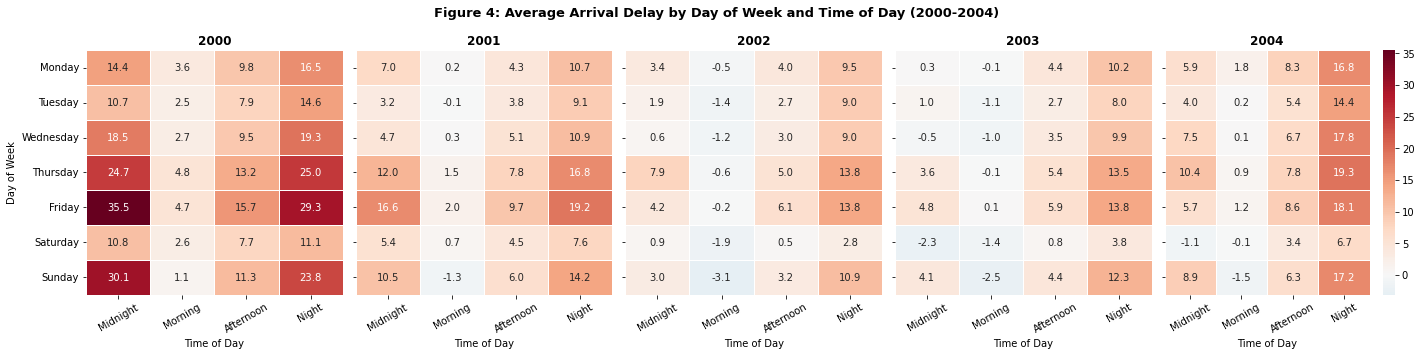

In [10]:
heatmap_df = pd.read_sql("""
  SELECT year,
         CASE dayofweek
           WHEN 1 THEN 'Monday'
           WHEN 2 THEN 'Tuesday'
           WHEN 3 THEN 'Wednesday'
           WHEN 4 THEN 'Thursday'
           WHEN 5 THEN 'Friday'
           WHEN 6 THEN 'Saturday'
           WHEN 7 THEN 'Sunday'
         END AS dayofweekstring,

         CASE 
           WHEN deptime <= 559 THEN 'Midnight'
           WHEN deptime <= 1159 THEN 'Morning'
           WHEN deptime <= 1759 THEN 'Afternoon'
           ELSE 'Night'
         END AS time_of_day,

         AVG(arrdelay) AS avg_delay

  FROM flights
  WHERE cancelled = 0
    AND diverted  = 0
    AND arrdelay IS NOT NULL
    AND deptime IS NOT NULL

  GROUP BY year, dayofweekstring, time_of_day
""", conn)

day_order  = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
time_order = ["Midnight", "Morning", "Afternoon", "Night"]

heatmap_df["dayofweekstring"] = pd.Categorical(heatmap_df["dayofweekstring"], categories=day_order,  ordered=True)
heatmap_df["time_of_day"]     = pd.Categorical(heatmap_df["time_of_day"],     categories=time_order, ordered=True)

years = sorted(heatmap_df["year"].unique())
fig, axes = plt.subplots(1, len(years), figsize=(20, 5), sharey=True)

vmin = heatmap_df["avg_delay"].min()
vmax = heatmap_df["avg_delay"].max()

for ax, yr in zip(axes, years):
    pivot = (
        heatmap_df[heatmap_df["year"] == yr]
        .pivot(index="dayofweekstring", columns="time_of_day", values="avg_delay")
        .reindex(index=day_order, columns=time_order)
    )
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".1f",
        cmap="RdBu_r", center=0, vmin=vmin, vmax=vmax,
        linewidths=0.5, linecolor="white",
        cbar=(ax == axes[-1])
    )
    ax.set_title(str(yr), fontweight="bold", fontsize=12)
    ax.set_xlabel("Time of Day")
    ax.set_ylabel("Day of Week" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Figure 4: Average Arrival Delay by Day of Week and Time of Day (2000-2004)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## Question 2B - Evaluate whether older planes suffer more delays on a year-to-year basis.

Loading plane-data.csv and storing it in a dataframe as planes_df.
Saving the dataframe into a sqlite database.

In [12]:
planes_df = pd.read_csv(os.path.join(DATA_FOLDER, "plane-data.csv"), encoding="latin1")
planes_df.to_sql("planes", conn, if_exists="replace", index=False)

We analyze data type of variables in plane data.

In [13]:
print(planes_df.dtypes)
print(planes_df.shape)
print(planes_df.head())

tailnum          object
type             object
manufacturer     object
issue_date       object
model            object
status           object
aircraft_type    object
engine_type      object
year             object
dtype: object
(5029, 9)
  tailnum type manufacturer issue_date model status aircraft_type engine_type  \
0  N050AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   
1  N051AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   
2  N052AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   
3  N054AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   
4  N055AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   

  year  
0  NaN  
1  NaN  
2  NaN  
3  NaN  
4  NaN  


tailnum variable will be used to link the flights and planes datasets to analyse whether older aircraft experience more delays so it becomes important to ensure that the values are standardised to avoid errors while merging.

We check if there are any lowercase letters in the Tailnum variable.
Likewise we check for invalid values in the year variable.

In [14]:
print(pd.read_sql("""
  SELECT COUNT(*) 
  FROM flights
  WHERE tailnum != UPPER(tailnum)
""", conn))

print(pd.read_sql("""
  SELECT 
    SUM(year = '0000'),
    SUM(year IS NULL),
    SUM(TRIM(year) = ''),
    SUM(year = 'None'),
    SUM(CAST(year AS INTEGER) < 1900)
  FROM planes
""", conn))

   COUNT(*)
0     13472
   SUM(year = '0000')  SUM(year IS NULL)  SUM(TRIM(year) = '')  \
0                   3                549                     0   

   SUM(year = 'None')  SUM(CAST(year AS INTEGER) < 1900)  
0                 145                                148  


Firstly a new table flights_clean is created from the flights Database, here tailnum_clean is generated by converting all values to lowercase using the LOWER() function to ensure all standardization. Rows with missing or empty tailnum values are excluded so that only valid identifiers are retained.

A second new table planes_clean is created from the original planes csv. Again the tailnum variable is standardized to lowercase to ensure consistency with the flights data. In addition, the year variable — representing the aircraft manufacturing year — is converted to an integer using CAST(), and invalid entries are removed.

In [15]:
# Check table existence helper
def table_exists(conn, name):
    cur = conn.execute("SELECT name FROM sqlite_master WHERE type='table' AND name=?", (name,))
    return cur.fetchone() is not None

if not table_exists(conn, "flights_clean"):
    conn.execute("""
        CREATE TABLE flights_clean AS
        SELECT *, LOWER(tailnum) AS tailnum_clean
        FROM flights
        WHERE tailnum IS NOT NULL AND tailnum != ''
    """)
    conn.commit()

if not table_exists(conn, "planes_clean"):
    conn.execute("""
        CREATE TABLE planes_clean AS
        SELECT 
          LOWER(tailnum) AS tailnum_clean,
          CAST(year AS INTEGER) AS year
        FROM planes
        WHERE tailnum IS NOT NULL 
          AND tailnum != ''
          AND TRIM(year) != ''
          AND TRIM(year) != '0000'
          AND CAST(year AS INTEGER) > 1900
    """)
    conn.commit()

To analyse the relationship between aircraft age and flight delays, a combined dataset age_df is created by joining the cleaned flights and planes tables using a common identifier (tailnum_clean).
Again CAST clause is used to convert year into integers and arrdelay into real in order to maintain standardization across, and WHERE clause is used to remove invalid data as done previously.

In [16]:
age_df = pd.read_sql("""
  SELECT 
    CAST(f.year AS INTEGER)  AS flight_year,
    f.tailnum_clean          AS tailnum,
    CAST(f.arrdelay AS REAL) AS arrdelay,
    CAST(p.year AS INTEGER)  AS plane_year
  FROM flights_clean f
  INNER JOIN planes_clean p
    ON f.tailnum_clean = p.tailnum_clean
  WHERE f.cancelled = 0
    AND f.diverted  = 0
    AND f.arrdelay IS NOT NULL
    AND p.year IS NOT NULL
""", conn)

Subtracting year of the flight from year when plane was manufactured, that is plane_year, in order to get the age of the plane at the time of the flight.

In [17]:
age_df["plane_age"] = age_df["flight_year"] - age_df["plane_year"]
print(age_df.head())

   flight_year tailnum  arrdelay  plane_year  plane_age
0         2000  n808aw       7.0        1999          1
1         2000  n653aw      40.0        1999          1
2         2000  n806aw      -7.0        1999          1
3         2000  n158aw      -4.0        1987         13
4         2000  n656aw      47.0        1999          1


In order to create a line plot, we first construct a summary dataset plane_age_summary from the merged dataset age_df. The data is grouped by plane_age, and for each age group, the average arrival delay is calculated using the mean of arrdelay. In addition, the number of flights (flight_count) for each age is computed to exclude age groups with fewer than 100 observations and this is done to ensure that the results are not driven by small sample sizes.

Using this plane_age_summary dataset, a line plot is generated with plane age on the x-axis and average arrival delay on the y-axis. The line represents how delays vary across different aircraft ages. Furthermore, a linear trend line is added to highlight the overall direction of the relationship between plane age and delays.

This visualisation allows us to assess whether older aircraft tend to experience higher or lower delays compared to newer ones.

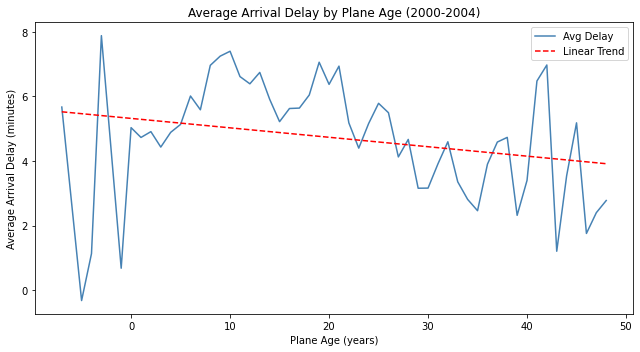

In [18]:
plane_age_summary = (
    age_df.groupby("plane_age")
    .agg(avg_delay=("arrdelay", "mean"), flight_count=("arrdelay", "count"))
    .reset_index()
    .query("flight_count > 100")
)

# Linear trend line
m, b, *_ = stats.linregress(plane_age_summary["plane_age"], plane_age_summary["avg_delay"])
trend_y   = m * plane_age_summary["plane_age"] + b

plt.figure(figsize=(9, 5))
plt.plot(plane_age_summary["plane_age"], plane_age_summary["avg_delay"],
         color="steelblue", label="Avg Delay")
plt.plot(plane_age_summary["plane_age"], trend_y,
         color="red", linestyle="--", label="Linear Trend")
plt.title("Average Arrival Delay by Plane Age (2000-2004)")
plt.xlabel("Plane Age (years)")
plt.ylabel("Average Arrival Delay (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

Similarly we compute the Spearman correlation coefficient for each year to complement the line plot.
Using age_df and grouping it with flight_year, for each year, the Spearman correlation between plane_age and arrdelay is calculated.

In [19]:
spearman_results = (
    age_df.dropna(subset=["plane_age", "arrdelay"])
    .groupby("flight_year")
    .apply(lambda g: stats.spearmanr(g["plane_age"], g["arrdelay"])[0])
    .reset_index()
)
spearman_results.columns = ["flight_year", "spearman_cor"]
print(spearman_results)

   flight_year  spearman_cor
0         2000     -0.019426
1         2001     -0.009068
2         2002      0.000223
3         2003     -0.006801
4         2004      0.042240


## Question 2C - For each year, fit a logistic regression model for the probability of diverted US flights using as many features as possible from attributes of the departure date, the scheduled departure and arrival times, the coordinates and distance between departure and planned arrival airports, and the carrier. Visualize the coefficients across years.

First we load the airports.csv and write it into the sql database.
Using the flights and airport_df a new table is constructed as flights_diverted, only variables that are available before the flight departs are included.

We do not include departure delay, taxi-out time and etc because those values are only known after the flight has already left.

Finally the flights table is joined with the airports dataset twice using LEFT JOIN to include origin and destination along with their latitude and longitude in the flights_diverted table and rows with invalid values for some variables are removed.

The main reason behind creating flights_diverted is that later to get the coefficients we would have to iterate five times — once per year using loops. If we didn't have this table, each iteration would have to join the full flights table with the airports table twice just to get the coordinates. Doing that join once upfront and saving the result is a lot faster than repeating it five times inside the loop.

In [20]:
airports_df = pd.read_csv(os.path.join(DATA_FOLDER, "airports.csv"))
airports_df.to_sql("airports", conn, if_exists="replace", index=False)

if not table_exists(conn, "flights_diverted"):
    conn.execute("""
        CREATE TABLE flights_diverted AS
        SELECT 
          f.year, f.month, f.dayofweek,
          f.uniquecarrier,
          f.crsdeptime, f.crsarrtime, f.crselapsedtime,
          f.distance, f.diverted,
          a1.lat  AS origin_lat, a1.long AS origin_lon,
          a2.lat  AS dest_lat,   a2.long AS dest_lon
        FROM flights f
        LEFT JOIN airports a1 ON f.origin = a1.iata
        LEFT JOIN airports a2 ON f.dest   = a2.iata
        WHERE f.cancelled = 0
          AND f.diverted  IS NOT NULL
          AND f.distance  IS NOT NULL
          AND f.crselapsedtime IS NOT NULL
    """)
    conn.commit()

Now we move on to fitting the logistic regression model for each year. In this step we loop through 2000 to 2004, pulling one year at a time from flights_diverted. For each year the numeric features are standardised so their coefficients are on the same scale, categorical variables are dummy-encoded and the data is split 70/30 into training and test sets. The model is then fit on the training data and the coefficients are extracted and stored. Memory is cleared after each year before moving to the next one. At the end all five years of coefficients are combined into a single data frame all_coef_df.

In [21]:
years     = list(range(2000, 2005))
coef_list = []
num_features = ["crsdeptime", "distance",
                "origin_lat", "origin_lon",
                "dest_lat", "dest_lon"]

for yr in years:
    print(f"Fitting year: {yr}")
    
    yr_df = pd.read_sql(f"""
        SELECT 
          diverted, month, dayofweek, uniquecarrier,
          crsdeptime, distance,
          origin_lat, origin_lon, dest_lat, dest_lon
        FROM flights_diverted
        WHERE year = {yr}
    """, conn)
    
    yr_df.columns = yr_df.columns.str.lower()
    yr_df = yr_df.dropna()
    #yr_df = yr_df.sample(n=min(1000000, len(yr_df)), random_state=42)
    
    # 1. Standardize numeric features
    scaler = StandardScaler()
    yr_df[num_features] = scaler.fit_transform(yr_df[num_features])
    
    # 2. Dummy encoding
    yr_df = pd.get_dummies(yr_df, columns=["uniquecarrier", "month", "dayofweek"], drop_first=True)
    
    X = yr_df.drop(columns=["diverted"])
    y = yr_df["diverted"].astype(int)
    
    # 3. Stratified 70/30 split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Fit model
    model = LogisticRegression(max_iter=1000, solver="lbfgs",C=1e9)
    model.fit(X_train, y_train)
    
    # Extract coefficients
    coefs = pd.DataFrame({
        "predictor": ["(Intercept)"] + list(X.columns),
        "estimate":  np.concatenate([model.intercept_, model.coef_[0]]),
        "year":      yr
    })
    coef_list.append(coefs)
    
    del yr_df, X, y, X_train, X_test, y_train, y_test, model
    gc.collect()

all_coef_df = pd.concat(coef_list, ignore_index=True)

Fitting year: 2000
Fitting year: 2001
Fitting year: 2002
Fitting year: 2003
Fitting year: 2004


In order to present the results from the logistic regression models, six variables are included in num_predictors.
Then they are iterated over each year from 2000 to 2004; for each year, the intercept of the logistic regression model is printed, representing the baseline log-odds of a flight being diverted when all predictors are at their reference levels.

The coefficients corresponding to the selected numerical predictors are then extracted from the combined coefficients dataset (all_coef_df) by filtering based on both the year and the predictor names. These coefficients are printed sequentially for each predictor.

In [22]:
num_predictors = ["crsdeptime", "distance",
                  "origin_lat", "origin_lon",
                  "dest_lat", "dest_lon"]

for yr in range(2000, 2005):
    print(f"Logistic Regression Model for Year {yr}:")

    intercept_val = all_coef_df.loc[
        (all_coef_df["year"] == yr) & (all_coef_df["predictor"] == "(Intercept)"),
        "estimate"
    ].values
    print(f"Intercept: {intercept_val[0] if len(intercept_val) else 'N/A'}")

    yr_coefs = all_coef_df[
        (all_coef_df["year"] == yr) &
        (all_coef_df["predictor"].isin(num_predictors))
    ]
    for _, row in yr_coefs.iterrows():
        print(f"{row['predictor']} : {row['estimate']}")
    print()

Logistic Regression Model for Year 2000:
Intercept: -5.747148599046808
crsdeptime : 0.12519777177656696
distance : 0.32580350564289967
origin_lat : 0.05111129248599927
origin_lon : 0.0877367125957469
dest_lat : 0.09082352210577449
dest_lon : 0.1669109249661291

Logistic Regression Model for Year 2001:
Intercept: -6.270498925783222
crsdeptime : -0.007712412531094092
distance : 0.31708911424343367
origin_lat : 0.0182866503006434
origin_lon : 0.13127546990383668
dest_lat : 0.058115095562271464
dest_lon : 0.13353432202749344

Logistic Regression Model for Year 2002:
Intercept: -6.504449718772493
crsdeptime : 0.08354816222802983
distance : 0.29035999673479956
origin_lat : 0.0694887480940111
origin_lon : 0.04769495654941769
dest_lat : 0.06338001171786375
dest_lon : 0.08386547348838028

Logistic Regression Model for Year 2003:
Intercept: -6.521108577679843
crsdeptime : 0.0038433635321937945
distance : 0.35782711693250574
origin_lat : 0.027833282395071338
origin_lon : 0.0524933306613876
dest_l

We plot the numeric predictor coefficients across all five years on a single figure. Each predictor gets its own coloured line showing how its relationship with diversion probability changes from 2000 to 2004. This directly answers the question of whether the factors driving diversion shifted over time.

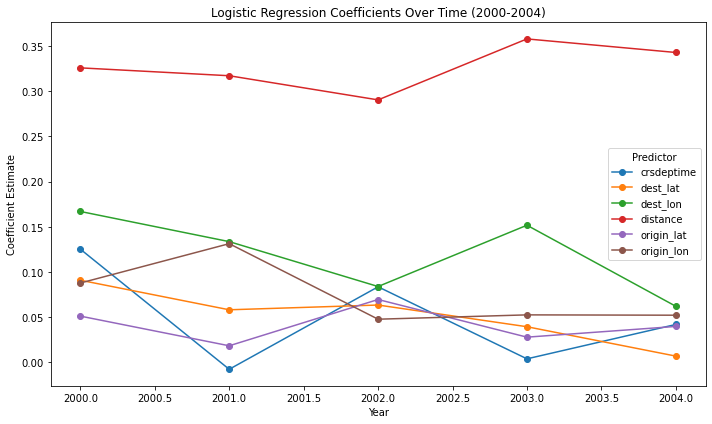

In [23]:
plot_df = all_coef_df[all_coef_df["predictor"].isin(num_predictors)]

plt.figure(figsize=(10, 6))
for pred, grp in plot_df.groupby("predictor"):
    plt.plot(grp["year"], grp["estimate"], marker="o", label=pred)

plt.title("Logistic Regression Coefficients Over Time (2000-2004)")
plt.xlabel("Year")
plt.ylabel("Coefficient Estimate")
plt.legend(title="Predictor")
plt.tight_layout()
plt.show()

closing the connection

In [ ]:
conn.close()